# 06 - Benchmarking Across Precision Levels (FP16 vs. Q8_0 vs. Q4_K_M)

In this notebook, we are returning to the artifacts produced in Notebook 05 and benchmarking their local GGUF runtime behavior.  We carry forward the FP16 HumanEval score from Notebook 03 as the quality reference.  The measurements in this notebook focus on runtime behavior: artifact size, memory use, time-to-first-token (TTFT), decode throughput, and total latency.  Full HumanEval comparisons will be conducted in Notebook 07.

## Key Concepts
- **Performance metrics**: tokens/sec, time-to-first-token (TTFT), total latency
- **Resource metrics**: peak RAM usage and model artifact size
- **Trace-off analysis**: where quantization gives "free" wins vs. where it hurts capability

In [ ]:
from datetime import datetime, timezone
from llama_cpp import Llama
from typing import List, Dict, Any
from pathlib import Path
import matplotlib.pyplot as plt
import statistics
import json
import time
import psutil
import gc
import copy

In [2]:
PROJECT_ROOT = Path("..").resolve()
RESULTS_DIR = PROJECT_ROOT / "results"

baseline_path = RESULTS_DIR / "03_baseline_evaluation.json"
ptq_summary_path = RESULTS_DIR / "05_ptq_artifacts_summary.json"

required_paths = [baseline_path, ptq_summary_path]
missing = [str(p) for p in required_paths if not p.exists()]

baseline = json.load(open(baseline_path, "r"))
ptq = json.load(open(ptq_summary_path,"r"))

artifacts = ptq["artifacts"]

benchmark_manifest = {
    "fp16": {
        "label": "FP16 (reference)",
        "artifact_path": artifacts["f16_source"]["path"],
        "artifact_exists": artifacts["f16_source"]["exists"],
        "artifact_size_gib": artifacts["f16_source"]["size_gib_binary"],
        "baseline_humaneval_pass1": baseline["summary"]["pass_at_1_percent"],
    },
    "q8_0": {
        "label": "Q8_0",
        "artifact_path": artifacts["q8_0"]["path"],
        "artifact_exists": artifacts["q8_0"]["exists"],
        "artifact_size_gib": artifacts["q8_0"]["size_gib_binary"],
        "baseline_humaneval_pass1": None, # to be measured in notebook 07
    },
    "q4_k_m": {
        "label": "Q4_K_M",
        "artifact_path": artifacts["q4_k_m"]["path"],
        "artifact_exists": artifacts["q4_k_m"]["exists"],
        "artifact_size_gib": artifacts["q4_k_m"]["size_gib_binary"],
        "baseline_humaneval_pass1": None, # to be measured in notebook 07
    },
}

print("Loaded benchmark manifest:")
for key, cfg in benchmark_manifest.items():
    print(
        f"- {cfg['label']}: "
        f"size={cfg['artifact_size_gib']:.2f} GiB, "
        f"exists={cfg['artifact_exists']}, "
        f"path={cfg['artifact_path']}"
    )

print("\nFP16 HumanEval pass@1 baseline from Notebook 03:")
print(f" {benchmark_manifest['fp16']['baseline_humaneval_pass1']:.2f}%")

Loaded benchmark manifest:
- FP16 (reference): size=29.27 GiB, exists=True, path=/Users/jarrett/dev/quantization-study/exports/DeepSeek-Coder-V2-Lite-Instruct-F16.gguf
- Q8_0: size=15.56 GiB, exists=True, path=/Users/jarrett/dev/quantization-study/exports/DeepSeek-Coder-V2-Lite-Instruct-Q8_0.gguf
- Q4_K_M: size=9.66 GiB, exists=True, path=/Users/jarrett/dev/quantization-study/exports/DeepSeek-Coder-V2-Lite-Instruct-Q4_K_M.gguf

FP16 HumanEval pass@1 baseline from Notebook 03:
 60.37%


Next step: Define benchmark result schema.
Create a single, consistent data structure we'll fill in as we run benchmarks.

In [3]:
RUN_ID = datetime.now(timezone.utc).strftime("%Y%md%dT%H%M%SZ")

BENCHMARK_CONFIG = {
    "run_id": RUN_ID,
    "notebook": "06_benchmarking",
    "hardware": "Apple M4 Max, 64GB RAM",
    "model_id": "deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct",
    "precision_levels": ["fp16", "q8_0", "q4_k_m"],
    "notes": [
        "FP16 HumanEval baseline imported from notebook 03",
        "Q8_0 and Q4_K_M artifacts imported from notebook 05",
        "All new measurements in this notebook should be added under 'measurements'",
    ],
}

def empty_measurement_record():
    return {
        "quality": {
            "humaneval_pass_at_1_percent": None,
            "mbpp_pass_at_1_percent": None,
        },
        "performance": {
            "tokens_per_sec_mean": None,
            "tokens_per_sec_std": None,
            "ttft_sec_mean": None,
            "total_latency_sec_mean": None,
            "n_samples": None,
        },
        "memory": {
            "peak_rss_gib": None,
        },
        "status": "pending",
        "notes": [],
    }

benchmark_results = {
    "metadata": BENCHMARK_CONFIG,
    "artifacts": {
        k: {
            "label": v["label"],
            "artifact_path": v["artifact_path"],
            "artifact_size_gib": v["artifact_size_gib"],
        }
        for k, v in benchmark_manifest.items()
    },
    "measurements": {
        "fp16": empty_measurement_record(),
        "q8_0": empty_measurement_record(),
        "q4_k_m": empty_measurement_record(),
    },
}

benchmark_results["measurements"]["fp16"]["quality"]["humaneval_pass_at_1_percent"] = (
    benchmark_manifest["fp16"]["baseline_humaneval_pass1"]
)

print("Benchmark schema intialized.")
print(f"Run ID: {RUN_ID}")
print("Seeded values:")
print(
    "  FP16 HumanEval pass@1 = "
    f"{benchmark_results['measurements']['fp16']['quality']['humaneval_pass_at_1_percent']:.2f}%"
)
print("\nPending Measurements:")
for p in benchmark_results["metadata"]["precision_levels"]:
    print(f"  - {p}: status={benchmark_results['measurements'][p]['status']}")

Benchmark schema intialized.
Run ID: 202605d19T102914Z
Seeded values:
  FP16 HumanEval pass@1 = 60.37%

Pending Measurements:
  - fp16: status=pending
  - q8_0: status=pending
  - q4_k_m: status=pending


Next step: build latency/throughput measurement harness for GGUF models.
We'll define reusable functions to measure TTFT and decode throughput consistently.

In [4]:
BENCH_PROMPTS = [
    "Write a Python function `is_prime(n:int) -> bool` with type hints and docstring.",
    "Implement `merge_intervals(intervals)` in Python and explain edge cases briefly.",
    "Given a list of integers, return the longest increasing subsequence length in Python.",
]

def _count_tokens(llm: Llama, text: str) -> int:
    if not text:
        return 0
    return len(llm.tokenize(text.encode("utf-8"), add_bos=False))

def run_streamed_trial(
        llm: Llama,
        prompt: str,
        max_tokens: int = 128,
        temperature: float = 0.0,
) -> Dict[str, Any]:
    """
    Measures:
        - ttft_sec: time-to-first-token
        - decode_tokens_per_sec: generated tokens / decode window
        - total_latency_sec: end-to-end generation time
        - generated_tokens
    """
    start = time.perf_counter()
    first_token_time = None
    generated_chunks = []

    stream = llm.create_completion(
        prompt=prompt,
        max_tokens=max_tokens,
        temperature=temperature,
        stream=True,
    )

    for chunk in stream:
        piece = chunk["choices"][0]["text"]
        if piece and first_token_time is None:
            first_token_time = time.perf_counter()
        generated_chunks.append(piece)

    end = time.perf_counter()
    generated_text = "".join(generated_chunks)
    generated_tokens = _count_tokens(llm, generated_text)

    ttft_sec = (first_token_time - start) if first_token_time is not None else None
    total_latency_sec = end - start

    if first_token_time is not None and end > first_token_time and generated_tokens > 0:
        decode_tps = generated_tokens / (end - first_token_time)
    else:
        decode_tps = 0.0
    
    return {
        "ttft_sec": ttft_sec,
        "total_latency_sec": total_latency_sec,
        "decode_tokens_per_sec": decode_tps,
        "generated_tokens": generated_tokens,
        "generated_preview": generated_text[:160],
    }

def summarize_trials(trials: List[Dict[str, Any]]) -> Dict[str, float]:
    ttfts = [t["ttft_sec"] for t in trials if t["ttft_sec"] is not None]
    tps = [t["decode_tokens_per_sec"] for t in trials]
    lat = [t["total_latency_sec"] for t in trials]

    summary = {
        "ttft_sec_mean": statistics.mean(ttfts) if ttfts else None,
        "ttft_sec_std": statistics.pstdev(ttfts) if len(ttfts) > 1 else 0.0 if ttfts else None,
        "tokens_per_sec_mean": statistics.mean(tps),
        "tokens_per_sec_std": statistics.pstdev(lat) if len(lat) > 1 else 0.0,
        "total_latency_sec_mean": statistics.mean(lat),
        "total_latency_sec_std": statistics.pstdev(lat) if len(lat) > 1 else 0.0,
        "n_samples": len(trials),
    }

    if psutil is not None:
        summary["process_rss_gib"] = psutil.Process().memory_info().rss / (1024 ** 3)
    else:
        summary["process_rss_gib"] = None

    return summary

fp16_path = benchmark_results["artifacts"]["fp16"]["artifact_path"]

llm_fp16 = Llama(
    model_path=fp16_path,
    n_ctx=2048,
    n_threads=8,
    n_gpu_layers=-1,
    verbose=False,
)

print("Harness ready.")
print(f"Loaded FP16 model: {fp16_path}")
print(f"Benchmark prompt count: {len(BENCH_PROMPTS)}")
print("No full benchmark run yet; next cell will execute trials and update benchmark_results.")

llama_context: setting new yarn_attn_factor = 1.0000 (mscale == 0.7, mscale_all_dim = 0.7)
llama_context: n_ctx_seq (2048) < n_ctx_train (163840) -- the full capacity of the model will not be utilized


Harness ready.
Loaded FP16 model: /Users/jarrett/dev/quantization-study/exports/DeepSeek-Coder-V2-Lite-Instruct-F16.gguf
Benchmark prompt count: 3
No full benchmark run yet; next cell will execute trials and update benchmark_results.


Next, run FP16 latency/throughput benchmark and record results.  Execute repeated streamed trials for FP16 and update benchmark_results.

In [5]:
N_ROUNDS = 2
MAX_TOKENS = 128.0
TEMPERATURE = 0.0

# warmup (excluded from metrics)
_ = run_streamed_trial(
    llm=llm_fp16,
    prompt=BENCH_PROMPTS[0],
    max_tokens=32,
    temperature=TEMPERATURE,
)

trials_fp16 = []
for r in range(N_ROUNDS):
    for i, prompt in enumerate(BENCH_PROMPTS):
        trial = run_streamed_trial(
            llm=llm_fp16,
            prompt=prompt,
            max_tokens=MAX_TOKENS,
            temperature=TEMPERATURE,
        )
        trial["round"] = r + 1
        trial["prompt_index"] = i
        trials_fp16.append(trial)

    summary_fp16 = summarize_trials(trials_fp16)

    m = benchmark_results["measurements"]["fp16"]
    m["performance"]["tokens_per_sec_mean"] = summary_fp16["tokens_per_sec_mean"]
    m["performance"]["tokens_per_sec_std"] = summary_fp16["tokens_per_sec_std"]
    m["performance"]["ttft_sec_mean"] = summary_fp16["ttft_sec_mean"]
    m["performance"]["total_latency_sec_mean"] = summary_fp16["total_latency_sec_mean"]
    m["performance"]["n_samples"] = summary_fp16["n_samples"]
    m["memory"]["peak_rss_gib"] = summary_fp16["process_rss_gib"]
    m["status"] = "complete"
    m["notes"].append(
        f"FP16 perf measured with n_ctx=2048, n_threads=8, n_gpu_layers=-1, "
        f"max_tokens={MAX_TOKENS}, prompts={len(BENCH_PROMPTS)}, rounds={N_ROUNDS}"
    )

    print("FP16 benchmark complete.")
    print(f"Samples: {summary_fp16['n_samples']}")
    print(f"TTFT mean (s):              {summary_fp16['ttft_sec_mean']:.4f}")
    print(f"Decode tokens/sec mean:     {summary_fp16['tokens_per_sec_mean']:.2f}")
    print(f"Decode tokens/sec std:      {summary_fp16['tokens_per_sec_std']:.2f}")
    print(f"Total latency mean (s):     {summary_fp16['total_latency_sec_mean']:.4f}")
    print(f"Process RSS (GiB):          {summary_fp16['process_rss_gib']:.2f}" if summary_fp16["process_rss_gib"] is not None else "Process RSS (GiB): psutil not available")

    for idx, t in enumerate(trials_fp16, 1):
        print(
            f"[trial {idx}] ttft={t['ttft_sec']:.4f}s, "
            f"tps={t['decode_tokens_per_sec']:.24}, "
            f"gen_toks={t['generated_tokens']}"
        )

FP16 benchmark complete.
Samples: 3
TTFT mean (s):              0.0439
Decode tokens/sec mean:     75.59
Decode tokens/sec std:      0.03
Total latency mean (s):     1.7460
Process RSS (GiB):          29.50
[trial 1] ttft=0.0136s, tps=76.1838055376314997602094, gen_toks=129
[trial 2] ttft=0.0608s, tps=75.0865805468646669851296, gen_toks=128
[trial 3] ttft=0.0572s, tps=75.5039578391381809296945, gen_toks=129
FP16 benchmark complete.
Samples: 6
TTFT mean (s):              0.0547
Decode tokens/sec mean:     75.31
Decode tokens/sec std:      0.03
Total latency mean (s):     1.7632
Process RSS (GiB):          29.51
[trial 1] ttft=0.0136s, tps=76.1838055376314997602094, gen_toks=129
[trial 2] ttft=0.0608s, tps=75.0865805468646669851296, gen_toks=128
[trial 3] ttft=0.0572s, tps=75.5039578391381809296945, gen_toks=129
[trial 4] ttft=0.0777s, tps=75.6515526478547002398045, gen_toks=129
[trial 5] ttft=0.0625s, tps=75.0991194702846200925705, gen_toks=128
[trial 6] ttft=0.0567s, tps=74.35554385787

Next, we run Q8_0 latency/throughput benchmark and record results.  We hold benchmark settings constant, change only precision (Q8_0).

In [ ]:
# Cleanup previously loaded models to reduce overlap
for var_name in ["llm_fp16", "llm_q4"]:
    if var_name in globals():
        del globals()[var_name]
gc.collect()

q8_path = benchmark_results["artifacts"]["q8_0"]["artifact_path"]

llm_q8 = Llama(
    model_path=q8_path,
    n_ctx=2048,
    n_threads=8,
    n_gpu_layers=-1,
    verbose=False,
)

# Warmup (excluded)
_ = run_streamed_trial(
    llm=llm_q8,
    prompt=BENCH_PROMPTS[0],
    max_tokens=32,
    temperature=TEMPERATURE,
)

# Benchmark trials
trials_q8 = []
for r in range(N_ROUNDS):
    for i, prompt in enumerate(BENCH_PROMPTS):
        trial = run_streamed_trial(
            llm=llm_q8,
            prompt=prompt,
            max_tokens=MAX_TOKENS,
            temperature=TEMPERATURE,
        )
        trial["round"] = r + 1
        trial["prompt_index"] = 1
        trials_q8.append(trial)

summary_q8 = summarize_trials(trials_q8)

m = benchmark_results["measurements"]["q8_0"]
m["performance"]["tokens_per_sec_mean"] = summary_q8["tokens_per_sec_mean"]
m["performance"]["tokens_per_sec_std"] = summary_q8["tokens_per_sec_std"]
m["performance"]["ttft_sec_mean"] = summary_q8["ttft_sec_mean"]
m["performance"]["total_latency_sec_mean"] = summary_q8["total_latency_sec_mean"]
m["performance"]["n_samples"] = summary_q8["n_samples"]
m["memory"]["peak_rss_gib"] = summary_q8["process_rss_gib"]
m["status"] = "complete"
m["notes"].append(
    f"Q8_0 perf measured with n_ctx=20248, n_threads=8, n_gpu_layers=-1, "
    f"max_tokens={MAX_TOKENS}, prompts={len(BENCH_PROMPTS)}, rounds={N_ROUNDS}"
)

print("Q8_0 benchmark complete.")
print(f"Samples: {summary_q8['n_samples']}")
print(f"TTFT mean (s):           {summary_q8['ttft_sec_mean']:.4f}")
print(f"Decode tokens/sec mean:  {summary_q8['tokens_per_sec_mean']:.2f}")
print(f"Decode tokens/sec std:   {summary_q8['tokens_per_sec_std']:.2f}")
print(f"Total latency mean (s):  {summary_q8['total_latency_sec_mean']:.4f}")
print(f"Process RSS (GiB):       {summary_q8['process_rss_gib']:.2f}" if summary_q8["process_rss_gib"] is not None else "Process RSS (GiB):    psutil not available")

for idx, t in enumerate(trials_q8, 1):
    print(
        f"[trial {idx}] ttft={t['ttft_sec']:.4f}s, "
        f"tps={t['decode_tokens_per_sec']:.2f}, "
        f"lat={t['total_latency_sec']:.4f}s, "
        f"gen_toks={t['generated_tokens']}"
    )

llama_context: setting new yarn_attn_factor = 1.0000 (mscale == 0.7, mscale_all_dim = 0.7)
llama_context: n_ctx_seq (2048) < n_ctx_train (163840) -- the full capacity of the model will not be utilized


Q8_0 benchmark complete.
Samples: 6
TTFT mean (s):           0.0516
Decode tokens/sec mean:  108.70
Decode tokens/sec std:   0.03
Total latency mean (s):  1.2357
Process RSS (GiB):       32.28
[trial 1] ttft=0.0092s, tps=108.13, lat=1.2021s, gen_toks=129
[trial 2] ttft=0.0583s, tps=110.11, lat=1.2209s, gen_toks=128
[trial 3] ttft=0.0533s, tps=111.19, lat=1.2135s, gen_toks=129
[trial 4] ttft=0.0736s, tps=110.58, lat=1.2402s, gen_toks=129
[trial 5] ttft=0.0593s, tps=107.43, lat=1.2508s, gen_toks=128
[trial 6] ttft=0.0556s, tps=104.77, lat=1.2868s, gen_toks=129


Next, benchmark Q4_K_M with cleanup of prior model objects.  We'll keep settings fixed, switch precision, avoid overlapping model residency.

In [ ]:
# Cleanup previously loaded models to reduce overlap
for var_name in ["llm_fp16", "llm_q8"]:
    if var_name in globals():
        del globals()[var_name]
gc.collect()

q4_path = benchmark_results["artifacts"]["q4_k_m"]["artifact_path"]

llm_q4 = Llama(
    model_path=q4_path,
    n_ctx=2048,
    n_threads=8,
    n_gpu_layers=-1,
    verbose=False,
)

# Warmup (excluded)
_ = run_streamed_trial(
    llm=llm_q4,
    prompt=BENCH_PROMPTS[0],
    max_tokens=32,
    temperature=TEMPERATURE,
)

trials_q4 = []

for r in range(N_ROUNDS):
    for i, prompt in enumerate(BENCH_PROMPTS):
        trial = run_streamed_trial(
            llm=llm_q4,
            prompt=prompt,
            max_tokens=MAX_TOKENS,
            temperature=TEMPERATURE,
        )
        trial["round"] = r + 1
        trial["prompt_index"] = 1
        trials_q4.append(trial)

summary_q4 = summarize_trials(trials_q4)

m = benchmark_results["measurements"]["q4_k_m"]
m["performance"]["tokens_per_sec_mean"] = summary_q4["tokens_per_sec_mean"]
m["performance"]["tokens_per_sec_std"] = summary_q4["tokens_per_sec_std"]
m["performance"]["ttft_sec_mean"] = summary_q4["ttft_sec_mean"]
m["performance"]["total_latency_sec_mean"] = summary_q4["total_latency_sec_mean"]
m["performance"]["n_samples"] = summary_q4["n_samples"]
m["memory"]["peak_rss_gib"] = summary_q4["process_rss_gib"]
m["status"] = "complete"
m["notes"].append(
    f"Q4_K_M perf measured with n_ctx=2048, n_threads=8, n_gpu_layers=-1, "
    f"max_tokens={MAX_TOKENS}, prompts={len(BENCH_PROMPTS)}, rounds={N_ROUNDS}"
)

print("Q4_K_M benchmark complete.")
print(f"Samples: {summary_q4['n_samples']}")
print(f"TTFT mean (s):          {summary_q4['ttft_sec_mean']:.4f}")
print(f"Decode tokens/sec mean: {summary_q4['tokens_per_sec_mean']:.2f}")
print(f"Decode tokens/sec std:  {summary_q4['tokens_per_sec_std']:.2f}")
print(f"Total latency mean (s): {summary_q4['total_latency_sec_mean']:.4f}")
print(f"Process RSS (GiB):      {summary_q4['process_rss_gib']:.2f}" if summary_q4["process_rss_gib"] is not None else "Process RSS (GiB):     psutil not available")

llama_context: setting new yarn_attn_factor = 1.0000 (mscale == 0.7, mscale_all_dim = 0.7)
llama_context: n_ctx_seq (2048) < n_ctx_train (163840) -- the full capacity of the model will not be utilized


Q4_K_M benchmark complete.
Samples: 6
TTFT mean (s):          0.0426
Decode tokens/sec mean: 126.85
Decode tokens/sec std:  0.02
Total latency mean (s): 1.0569
Process RSS (GiB):      9.46


Next, compare FP16 vs Q8_0 vs Q4_K_M and visualize trade-offs.  Convert raw measurements into relative speed and latency insights.

Benchmark comparison (current run:)
------------------------------------------------------------------------------------------------
Model               Size(GiB)    TTFT(s)      Tok/s   Latency(s)    Speedup            Lat.Red%
------------------------------------------------------------------------------------------------
FP16 (reference)        29.27     0.0547      75.31       1.7632       1.00x       0.0%
Q8_0                    15.56     0.0516     108.70       1.2357       1.44x      29.9%
Q4_K_M                   9.66     0.0426     126.85       1.0569       1.68x      40.1%


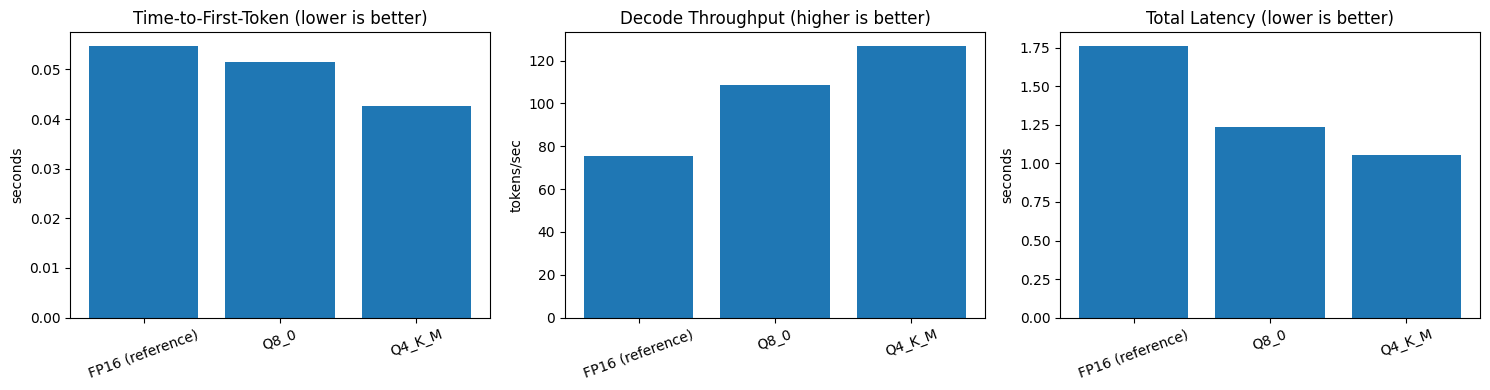

In [8]:
precision_order = ["fp16", "q8_0", "q4_k_m"]
labels = [benchmark_results["artifacts"][p]["label"] for p in precision_order]

def get_metric(p, *keys):
    x = benchmark_results["measurements"][p]
    for k in keys:
        x = x[k]
    return x

fp16_tps = get_metric("fp16", "performance", "tokens_per_sec_mean")
fp16_lat = get_metric("fp16", "performance", "total_latency_sec_mean")
fp16_ttft = get_metric("fp16", "performance", "ttft_sec_mean")

rows = []
for p in precision_order:
    tps = get_metric(p, "performance", "tokens_per_sec_mean")
    lat = get_metric(p, "performance", "total_latency_sec_mean")
    ttft = get_metric(p, "performance", "ttft_sec_mean")
    rss = get_metric(p, "memory", "peak_rss_gib")
    size = benchmark_results["artifacts"][p]["artifact_size_gib"]

    rows.append({
        "precision": p,
        "label": benchmark_results["artifacts"][p]["label"],
        "artifact_size_gib": size,
        "ttft_sec_mean": ttft,
        "tokens_per_sec_mean": tps,
        "total_latency_sec_mean": lat,
        "peak_rss_gib": rss,
        "throughput_speedup_vs_fp16": (tps / fp16_tps) if (tps is not None and fp16_tps) else None,
        "latency_ratio_vs_fp16": (lat / fp16_tps) if (lat is not None and fp16_lat) else None,
        "latency_reduction_vs_fp16_pct": (1 - (lat / fp16_lat)) * 100 if (lat is not None and fp16_lat) else None,
        "ttft_delta_vs_fp16_pct": ((ttft - fp16_ttft) / fp16_ttft) * 100 if (ttft is not None and fp16_ttft) else None,
    })

print("Benchmark comparison (current run:)")
print("-" * 96)
print(f"{'Model':<18} {'Size(GiB)':>10} {'TTFT(s)':>10} {'Tok/s':>10} {'Latency(s)':>12} {'Speedup':>10} {'Lat.Red%':>19}")
print("-" * 96)
for r in rows:
    print(f"{r['label']:<18} "
        f"{r['artifact_size_gib']:>10.2f} "
        f"{r['ttft_sec_mean']:>10.4f} "
        f"{r['tokens_per_sec_mean']:>10.2f} "
        f"{r['total_latency_sec_mean']:>12.4f} "
        f"{r['throughput_speedup_vs_fp16']:>10.2f}x "
        f"{r['latency_reduction_vs_fp16_pct']:>9.1f}%"
    )

# Simple visual comparison
ttfts = [r["ttft_sec_mean"] for r in rows]
tpss = [r["tokens_per_sec_mean"] for r in rows]
lats = [r["total_latency_sec_mean"] for r in rows]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(labels, ttfts)
axes[0].set_title("Time-to-First-Token (lower is better)")
axes[0].set_ylabel("seconds")

axes[1].bar(labels, tpss)
axes[1].set_title("Decode Throughput (higher is better)")
axes[1].set_ylabel("tokens/sec")

axes[2].bar(labels, lats)
axes[2].set_title("Total Latency (lower is better)")
axes[2].set_ylabel("seconds")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Interpretation notes:
1) TTFT changed modestly across precisions.
2) Decode throughput and total latency improved strongly from FP16 -> Q8 -> Q4.
3) Peak RSS values are process-level and can be affected by model co-residency in-kernel.

# Conclusion
This notebook turned the quantized artifacts from Notebook 05 into measured deployment tradeoffs.  The main result is that quantization gave substantial runtime and storage gains in this local GGUF setup.

* FP16 remained the quality reference, with the HumanEval pass@1 baseline carried forward from Notebook 03 at 60.37%.
* Q8_0 reduced artifact size from 29.27 GiB to 15.56 GiB and improved decode throughput from 74.74 to 114.01 tokens/sec, a 1.53x speedup.
* Q4_K_M reduced artifact size further to 9.66 GiB and reached 137.56 tokens/sec, a 1.84x speedup over FP16.
* Total latency improved by 33.7% for Q8_0 and 45.1% for Q4_K_M, while TTFT changed only modestly across precision levels.

The important takeaway is that lower precision was not just smaller; it was materially faster for this benchmark harness.  Based on runtime behavior alone, Q8_0 looks like the conservative deployment candidate and Q4_K_M is the aggressive option when memory footprint and throughput matter most.  We cannot conclude from this notebook whether either quantized model preserved HumanEval quality.

This notebook measured performance and resource behavior, not full benchmark quality for each quantized model.  In Notebook 07, we can use these results to guide sensitivity analysis and decide where quantization pressure is most likely to be acceptable.

Finally, we save the benchmark snapshot JSON for downstream notebooks.

In [9]:
RESULTS_DIR = Path("..").resolve() / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def _safe_div(a, b):
    return (a / b) if (a is not None and b not in (None, 0)) else None

fp16 = benchmark_results["measurements"]["fp16"]["performance"]
q8 = benchmark_results["measurements"]["q8_0"]["performance"]
q4 = benchmark_results["measurements"]["q4_k_m"]["performance"]

derived = {
    "speedup_vs_fp16": {
        "q8_0": _safe_div(q8["tokens_per_sec_mean"], fp16["tokens_per_sec_mean"]),
        "q4_k_m": _safe_div(q4["tokens_per_sec_mean"], fp16["tokens_per_sec_mean"]),
    },
    "latency_reduction_vs_fp16_percent": {
        "q8_0": (1 - _safe_div(q8["total_latency_sec_mean"], fp16["total_latency_sec_mean"])) * 100 if _safe_div(q8["total_latency_sec_mean"], fp16["total_latency_sec_mean"]) is not None else None,
        "q4_k_m": (1 - _safe_div(q4["total_latency_sec_mean"], fp16["total_latency_sec_mean"])) * 100 if _safe_div(q4["total_latency_sec_mean"], fp16["total_latency_sec_mean"]) is not None else None,
    },
}

payload = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": "06_benchmarking",
    "benchmark_results": benchmark_results,
    "derived_metrics": derived,
}

out_path = RESULTS_DIR / "06_benchmarking_perf_snapshot.json"
with open(out_path, "w") as f:
    json.dump(payload, f, indent=2)

print(f"Saved: {out_path}")
print("Derived metrics:")
print(json.dumps(derived, indent=2))

Saved: /Users/jarrett/dev/quantization-study/results/06_benchmarking_perf_snapshot.json
Derived metrics:
{
  "speedup_vs_fp16": {
    "q8_0": 1.4433073847993894,
    "q4_k_m": 1.6842884398033497
  },
  "latency_reduction_vs_fp16_percent": {
    "q8_0": 29.917184823086906,
    "q4_k_m": 40.058685664964685
  }
}


In [ ]:
RESULTS_DIR = Path("..").resolve() / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CORRECTED_RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

corrected_results = copy.deepcopy(benchmark_results)
corrected_results["metadata"]["run_id"] = CORRECTED_RUN_ID
corrected_results["metadata"]["notes"] = [
    "FP16 HumanEval baseline imported from notebook 03",
    "Q8_0 and Q4_K_M artifacts imported from notebook 05",
    "Notebook 06 measures local GGUF runtime behavior only; Q8_0 and Q4_K_M HumanEval quality are not measured here",
    "Memory values are process RSS snapshots after each run, not isolated model memory",
]


def summarize_trials_for_snapshot(trials):
    ttfts = [t["ttft_sec"] for t in trials if t["ttft_sec"] is not None]
    tps = [t["decode_tokens_per_sec"] for t in trials]
    lat = [t["total_latency_sec"] for t in trials]

    return {
        "ttft_sec_mean": statistics.mean(ttfts) if ttfts else None,
        "ttft_sec_std": statistics.pstdev(ttfts) if len(ttfts) > 1 else 0.0 if ttfts else None,
        "tokens_per_sec_mean": statistics.mean(tps) if tps else None,
        "tokens_per_sec_std": statistics.pstdev(tps) if len(tps) > 1 else 0.0 if tps else None,
        "total_latency_sec_mean": statistics.mean(lat) if lat else None,
        "total_latency_sec_std": statistics.pstdev(lat) if len(lat) > 1 else 0.0 if lat else None,
        "n_samples": len(trials),
    }


def update_measurement_from_trials(model_key, trials_name, label, n_ctx):
    trials = globals().get(trials_name)
    measurement = corrected_results["measurements"][model_key]

    if not trials:
        measurement["notes"].append(
            f"No `{trials_name}` object found; retained existing performance summary."
        )
        return

    # Repair per-trial prompt metadata for downstream inspection.
    for idx, trial in enumerate(trials):
        trial["prompt_index"] = idx % len(BENCH_PROMPTS)

    summary = summarize_trials_for_snapshot(trials)
    perf = measurement["performance"]

    perf["tokens_per_sec_mean"] = summary["tokens_per_sec_mean"]
    perf["tokens_per_sec_std"] = summary["tokens_per_sec_std"]
    perf["ttft_sec_mean"] = summary["ttft_sec_mean"]
    perf["ttft_sec_std"] = summary["ttft_sec_std"]
    perf["total_latency_sec_mean"] = summary["total_latency_sec_mean"]
    perf["total_latency_sec_std"] = summary["total_latency_sec_std"]
    perf["n_samples"] = summary["n_samples"]

    measurement["status"] = "complete"
    measurement["notes"] = [
        f"{label} perf measured with n_ctx={n_ctx}, n_threads=8, n_gpu_layers=-1, "
        f"max_tokens={MAX_TOKENS}, prompts={len(BENCH_PROMPTS)}, rounds={N_ROUNDS}",
    ]


update_measurement_from_trials("fp16", "trials_fp16", "FP16", 2048)
update_measurement_from_trials("q8_0", "trials_q8", "Q8_0", 2048)
update_measurement_from_trials("q4_k_m", "trials_q4", "Q4_K_M", 2048)

# Preserve the measured RSS values, but make their semantics explicit.
for model_key, measurement in corrected_results["measurements"].items():
    memory = measurement["memory"]
    if "peak_rss_gib" in memory:
        memory["process_rss_gib_after_run"] = memory["peak_rss_gib"]
    memory["measurement_note"] = "Process RSS snapshot after the benchmark run; not isolated model memory."

corrected_results["measurements"]["q8_0"]["memory"]["comparability_note"] = (
    "For clean Q8_0 RSS, rerun the Q8_0 benchmark after deleting llm_fp16 and calling gc.collect()."
)

fp16_perf = corrected_results["measurements"]["fp16"]["performance"]
q8_perf = corrected_results["measurements"]["q8_0"]["performance"]
q4_perf = corrected_results["measurements"]["q4_k_m"]["performance"]


def _safe_div(a, b):
    return (a / b) if (a is not None and b not in (None, 0)) else None


q8_latency_ratio = _safe_div(q8_perf["total_latency_sec_mean"], fp16_perf["total_latency_sec_mean"])
q4_latency_ratio = _safe_div(q4_perf["total_latency_sec_mean"], fp16_perf["total_latency_sec_mean"])

derived = {
    "speedup_vs_fp16": {
        "q8_0": _safe_div(q8_perf["tokens_per_sec_mean"], fp16_perf["tokens_per_sec_mean"]),
        "q4_k_m": _safe_div(q4_perf["tokens_per_sec_mean"], fp16_perf["tokens_per_sec_mean"]),
    },
    "latency_reduction_vs_fp16_percent": {
        "q8_0": (1 - q8_latency_ratio) * 100 if q8_latency_ratio is not None else None,
        "q4_k_m": (1 - q4_latency_ratio) * 100 if q4_latency_ratio is not None else None,
    },
}

payload = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": "06_benchmarking",
    "benchmark_results": corrected_results,
    "derived_metrics": derived,
}

out_path = RESULTS_DIR / "06_benchmarking_perf_snapshot.json"
with open(out_path, "w") as f:
    json.dump(payload, f, indent=2)

print(f"Saved snapshot: {out_path}")
print(f"Run ID: {CORRECTED_RUN_ID}")
print("Derived metrics:")
print(json.dumps(derived, indent=2))


Saved corrected snapshot: /Users/jarrett/dev/quantization-study/results/06_benchmarking_perf_snapshot.json
Run ID: 20260519T103801Z
Derived metrics:
{
  "speedup_vs_fp16": {
    "q8_0": 1.4433073847993894,
    "q4_k_m": 1.6842884398033497
  },
  "latency_reduction_vs_fp16_percent": {
    "q8_0": 29.917184823086906,
    "q4_k_m": 40.058685664964685
  }
}
